# Sesi 11 - Intro Machine Learning

Machine learning adalah cara membuat komputer belajar dari data untuk membuat prediksi
Kita akan membuat model prediksi sederhana menggunakan dataset Superstore.csv

Yang akan kita pelajari bersama, diantaranya adalah:
1. Konsep dasar ML (machine learning) yang terdiri dari train/test split
2. Linear Regression - prediksi angka
3. Evaluasi Model

## 1. Persiapan Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv("samplesuperstore.csv", encoding="latin1")

In [5]:
#Kita akan memprediksi Profit berdasarkan Sales & Discount
X = df[["Sales", "Discount", "Quantity"]] #fitur (input)
y = df[["Profit"]]                        #target (output)

print("Fitur (X):")
print(X.head())
print("\nTarget (y): ")
print(y.head())

Fitur (X):
     Sales  Discount  Quantity
0   16.448       0.2         2
1    3.540       0.8         2
2   11.784       0.2         3
3  272.736       0.2         3
4   19.536       0.2         3

Target (y): 
    Profit
0   5.5512
1  -5.4870
2   4.2717
3 -64.7748
4   4.8840


## 2. Split Data - Train & Test

In [7]:
# 80% Data untuk Training, 20% Data untuk Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data Training : {X_train.shape[0]} baris")
print(f"Data Testing : {X_test.shape[0]} baris")

Data Training : 8155 baris
Data Testing : 2039 baris


## 3. Training Model

In [19]:
# Buat dan training model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model selesai di-training!")
print(f"\nKoefisien:")
for fitur, koef in zip(X.columns, model.coef_.flatten()):
    print(f"  {fitur}: {koef:.4f}")
print(f"\nIntercept: {float(model.intercept_):.4f}")

Model selesai di-training!

Koefisien:
  Sales: 0.1212
  Discount: -247.3631
  Quantity: 0.5564

Intercept: 35.1300


/var/folders/cq/w6sqyz0x73392v8yl0qxbrx00000gn/T/ipykernel_25095/908579021.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"\nIntercept: {float(model.intercept_):.4f}")


## 4. Evaluasi Model

In [23]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE (rata-rata error): ${mae:.2f}")
print(f"R² Score             : {r2:.4f}")
print(f"\nArtinya: model menjelaskan {r2*100:.1f}% variasi profit")

MAE (rata-rata error): $61.34
R² Score             : 0.3998

Artinya: model menjelaskan 40.0% variasi profit


## 5. Visualisasi Prediksi vs Aktual

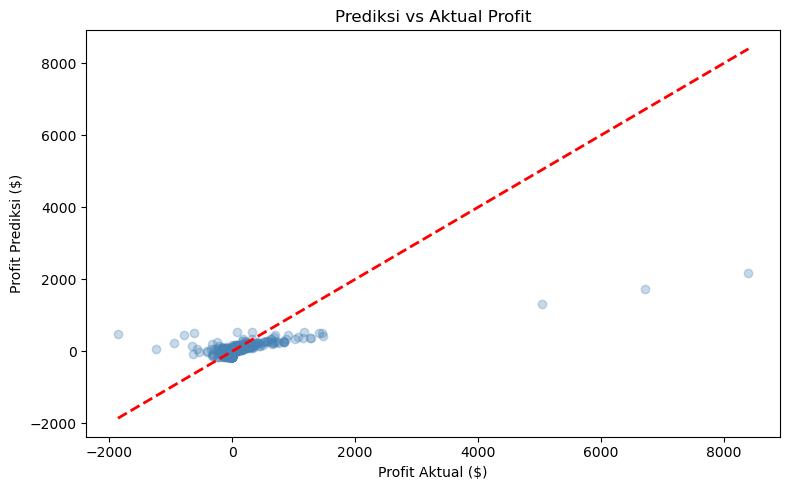

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, linestyle="--")
plt.title("Prediksi vs Aktual Profit")
plt.xlabel("Profit Aktual ($)")
plt.ylabel("Profit Prediksi ($)")
plt.tight_layout()
plt.show()